In [ ]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
from google.colab import files

# 1. Upload Kaggle JSON
print("🔑 Please upload your kaggle.json file:")
uploaded = files.upload()

if 'kaggle.json' not in uploaded:
    raise FileNotFoundError("You didn't upload kaggle.json!")

# 2. Setup Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Download the specific 5500-image dataset
print("📥 Downloading 5.5k Fashion Dataset...")
!kaggle datasets download -d paramaguru/fashion-product-images-small --force
!unzip -q fashion-product-images-small.zip

print("\n💎 DONE: styles.csv and images/ folder are ready.")

🔑 Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
📥 Downloading 5.5k Fashion Dataset...
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata

💎 DONE: styles.csv and images/ folder are ready.


In [ ]:
import os
import pandas as pd

# 1. Unzip manually
if os.path.exists('fashion-product-images-small.zip'):
    print("📦 Unzipping...")
    !unzip -q fashion-product-images-small.zip
    print("✅ Unzipped successfully.")
else:
    print("ZIP file not found in sidebar. Please upload it first!")

# 2. Check the files
if os.path.exists('styles.csv'):
    df_raw = pd.read_csv("styles.csv", on_bad_lines='skip', encoding='ISO-8859-1')
    df_raw.columns = df_raw.columns.str.strip()

    # Filter for the "Big Three"
    target_cats = ['Topwear', 'Bottomwear', 'Shoes']
    df_verify = df_raw[df_raw['subCategory'].isin(target_cats)].copy()

    # Filter for items that actually have images
    df_verify = df_verify[df_verify['id'].apply(lambda x: os.path.exists(f"images/{int(x)}.jpg"))]

    print("\n ACTUAL SUCCESS:")
    print(df_verify['subCategory'].value_counts())
else:
    print(" styles.csv still missing. The unzip failed or the zip was empty.")

📦 Unzipping...
replace images/10000.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
✅ Unzipped successfully.

💎 ACTUAL SUCCESS:
subCategory
Topwear       15398
Shoes          7343
Bottomwear     2693
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans
import cv2
import numpy as np

def get_dominant_color_kmeans(img_path, k=3):
    try:
        # Load and resize for speed
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (100, 100))

        pixels = img.reshape((-1, 3))
        kmeans = KMeans(n_clusters=k, n_init=10)
        kmeans.fit(pixels)

        colors = kmeans.cluster_centers_
        counts = np.bincount(kmeans.labels_)

        # Sort clusters by size (most frequent first)
        ordered_indices = np.argsort(counts)[::-1]

        # Skip the background: If color is too white (>240), move to next cluster
        for idx in ordered_indices:
            color = colors[idx]
            if not (color[0] > 240 and color[1] > 240 and color[2] > 240):
                return color.astype(int).tolist()

        return colors[ordered_indices[0]].astype(int).tolist() # Fallback
    except:
        return [128, 128, 128]

# Create a manageable subset (1000 per category) for the demo
df_subset = df_verify.groupby('subCategory').apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)).reset_index(drop=True)

print("🎨 Extracting Color DNA (K-Means)... This will take ~2-4 minutes.")
df_subset['rgb_cluster'] = df_subset['id'].apply(lambda x: get_dominant_color_kmeans(f"images/{int(x)}.jpg"))
print("✅ Colors Extracted.")

/tmp/ipykernel_14197/241044230.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_subset = df_verify.groupby('subCategory').apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)).reset_index(drop=True)


🎨 Extracting Color DNA (K-Means)... This will take ~2-4 minutes.
✅ Colors Extracted.


In [ ]:
def rgb_to_fashion_label(rgb):
    r, g, b = rgb
    # Logic for your 13-color palette
    if r < 50 and g < 50 and b < 50: return "Black"
    if r > 230 and g > 230 and b > 230: return "White"

    # Check for strong color presence
    if b > r and b > g: return "Navy" if b < 140 else "Blue"
    if r > g and r > b: return "Maroon" if r < 140 else "Red"
    if g > r and g > b: return "Olive" if g < 140 else "Green"

    # Earth tones
    if r > 160 and g > 140 and b < 120: return "Beige"
    if r > 100 and g > 70 and b < 60: return "Brown"
    if abs(r-g) < 20 and abs(g-b) < 20: return "Grey"

    return "Pattern" # Fallback for complex colors

df_subset['final_color_cat'] = df_subset['rgb_cluster'].apply(rgb_to_fashion_label)

print("🎯 Final Color Distribution for your Closet:")
print(df_subset['final_color_cat'].value_counts())

🎯 Final Color Distribution for your Closet:
final_color_cat
Red        1010
Navy        539
Maroon      441
Black       356
Blue        286
Olive       122
Grey        119
Green        92
White        28
Pattern       7
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image

# 1. Load the "Style Expert" (Pre-trained on millions of images)
model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

def extract_style_features(img_id):
    try:
        img_path = f"/content/images/{int(img_id)}.jpg"
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)

        features = model.predict(x, verbose=0)
        return features.flatten()
    except:
        return np.zeros(1280)

print("🚀 Extracting Style DNA Fingerprints... (Takes ~3-5 mins for 3000 items)")
# We apply this to our subset
style_embeddings = np.array([extract_style_features(id) for id in df_subset['id']])
print(" Style DNA successfully mapped to all items.")

/tmp/ipykernel_14197/2138066528.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
🚀 Extracting Style DNA Fingerprints... (Takes ~3-5 mins for 3000 items)
✅ Style DNA successfully mapped to all items.


In [ ]:
import numpy as np
import cv2
from sklearn.cluster import KMeans

# 1. THE FOCUSED COLOR DETECTOR
def get_dominant_color_focused(img_path, k=3):
    try:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # CENTER CROP: Focus on the item, ignore the edges
        h, w, _ = img.shape
        img = img[int(h*0.2):int(h*0.8), int(w*0.2):int(w*0.8)]

        # Filter out white pixels BEFORE clustering
        pixels = cv2.resize(img, (80, 80)).reshape((-1, 3))
        non_white = pixels[np.all(pixels < 235, axis=1)]

        if len(non_white) < 100: non_white = pixels # Fallback if item is white

        kmeans = KMeans(n_clusters=k, n_init=5)
        kmeans.fit(non_white)
        return kmeans.cluster_centers_[np.argmax(np.bincount(kmeans.labels_))].astype(int).tolist()
    except:
        return [128, 128, 128]

# 2. THE EXPERT RANKING MATRIX (Your specific fashion logic)
expert_ranks = {
    'Navy':  ['Beige', 'Khaki', 'White', 'Grey', 'Brown', 'Red', 'Olive', 'Maroon', 'Black', 'Blue', 'Green', 'Pattern', 'Navy'],
    'Black': ['White', 'Grey', 'Blue', 'Red', 'Maroon', 'Khaki', 'Beige', 'Pattern', 'Olive', 'Navy', 'Brown', 'Green', 'Black'],
    'White': ['Black', 'Navy', 'Grey', 'Beige', 'Khaki', 'Brown', 'Blue', 'Olive', 'Maroon', 'Red', 'Green', 'Pattern', 'White'],
    'Red':   ['Black', 'Navy', 'White', 'Grey', 'Blue', 'Beige', 'Pattern', 'Khaki', 'Olive', 'Maroon', 'Brown', 'Green', 'Red'],
    'Maroon':['Beige', 'White', 'Black', 'Grey', 'Navy', 'Khaki', 'Olive', 'Blue', 'Pattern', 'Green', 'Brown', 'Red', 'Maroon']
}

def get_expert_score(seed_color, candidate_color):
    ranks = expert_ranks.get(seed_color, ['White', 'Black', 'Grey', 'Navy', 'Brown', 'Beige', 'Olive', 'Khaki', 'Red', 'Blue', 'Green', 'Maroon', 'Pattern'])
    try:
        return 1 - (ranks.index(candidate_color) / 12)
    except:
        return 0.5

# 3. RUN THE UPDATE
print(" Re-extracting focused colors...")
df_subset['rgb_cluster'] = df_subset['id'].apply(lambda x: get_dominant_color_focused(f"/content/images/{int(x)}.jpg"))

def map_label_v2(rgb):
    r, g, b = rgb
    if max(rgb) < 60: return "Black"
    if min(rgb) > 230: return "White"
    if b > r * 1.2 and b > g * 1.2: return "Navy" if b < 130 else "Blue"
    if r > g * 1.2 and r > b * 1.2: return "Maroon" if r < 130 else "Red"
    if g > r * 1.1 and g > b * 1.1: return "Olive" if g < 130 else "Green"
    return "Grey"

df_subset['final_color_cat'] = df_subset['rgb_cluster'].apply(map_label_v2)
print(" Done. Ready for the final generate_outfit test!")

🎯 Re-extracting focused colors...
✅ Done. Ready for the final generate_outfit test!


✨ Styling for Men: United Colors of Benetton Men Blue Check Shirt (Grey)


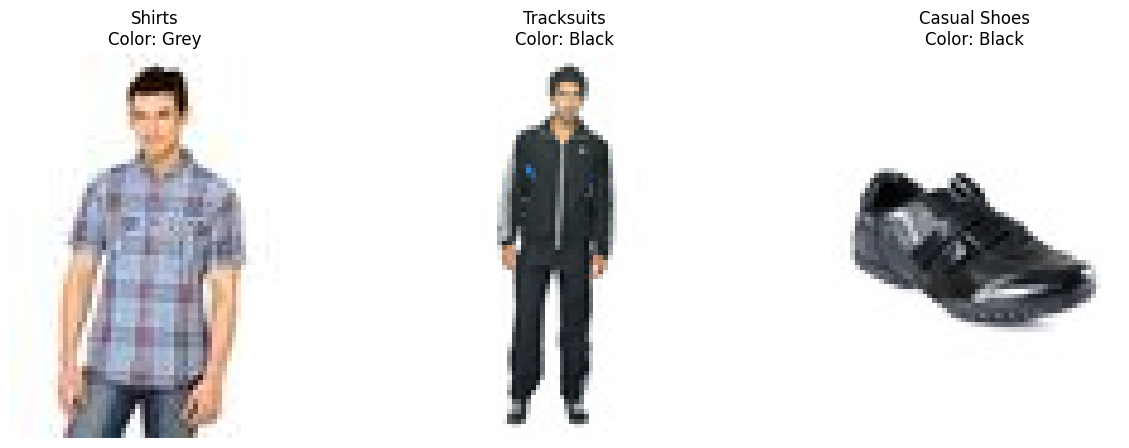

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Your 13-color Palette
ideal_colors = ['White', 'Black', 'Grey', 'Navy', 'Brown', 'Beige', 'Olive', 'Khaki', 'Red', 'Blue', 'Green', 'Maroon', 'Pattern']

def generate_outfit_final(seed_id):
    # Get seed item info
    seed_idx = df_subset.index[df_subset['id'] == seed_id][0]
    seed_item = df_subset.loc[seed_idx]
    seed_color = seed_item['final_color_cat']
    seed_vec = style_embeddings[seed_idx]

    print(f"✨ Styling for {seed_item['gender']}: {seed_item['productDisplayName']} ({seed_color})")

    def find_match(category):
        # 1. Filter by category AND gender (matching seed item)
        pool = df_subset[
            (df_subset['subCategory'] == category) &
            ((df_subset['gender'] == seed_item['gender']) | (df_subset['gender'] == 'Unisex'))
        ].copy()

        if pool.empty: return None

        # 2. Get the specific row indices from the original style_embeddings matrix
        pool_indices = pool.index.tolist()

        # 3. Calculate scores
        # We slice the embeddings matrix using the indices of our filtered pool
        style_scores = cosine_similarity([seed_vec], style_embeddings[pool_indices])[0]
        color_scores = pool['final_color_cat'].apply(lambda x: get_expert_score(seed_color, x)).values

        # 4. Final Scoring (Weighted)
        pool['final_score'] = (color_scores * 0.6) + (style_scores * 0.4)
        return pool.sort_values('final_score', ascending=False).iloc[0]

    # Run the matcher
    bottom = find_match('Bottomwear')
    shoe = find_match('Shoes')
    outfit = [seed_item, bottom, shoe]

    # Visualization
    plt.figure(figsize=(15, 5))
    for i, item in enumerate(outfit):
        if item is not None:
            plt.subplot(1, 3, i+1)
            plt.imshow(plt.imread(f"/content/images/{int(item['id'])}.jpg"))
            plt.title(f"{item['articleType']}\nColor: {item['final_color_cat']}")
            plt.axis('off')
    plt.show()

# --- TEST IT ---
random_top = df_subset[df_subset['subCategory'] == 'Topwear'].sample(1)['id'].values[0]
generate_outfit_final(random_top)

👔 --- STRICT 3x3 LOOKBOOK GENERATOR --- 👔
(Note: Inputs are CASE-SENSITIVE. Type 'v' to see exact dataset values.)

1. Enter Gender (e.g., Men, Women): Men
2. Enter Item Type (e.g., Shirts, Tshirts, Jackets): Shirts
3. Enter Color (e.g., Navy, Black, White): v
👉 Available Colors: White, Black, Grey, Navy, Brown, Beige, Olive, Khaki, Red, Blue, Green, Maroon, Pattern
3. Enter Color (e.g., Navy, Black, White): Navy


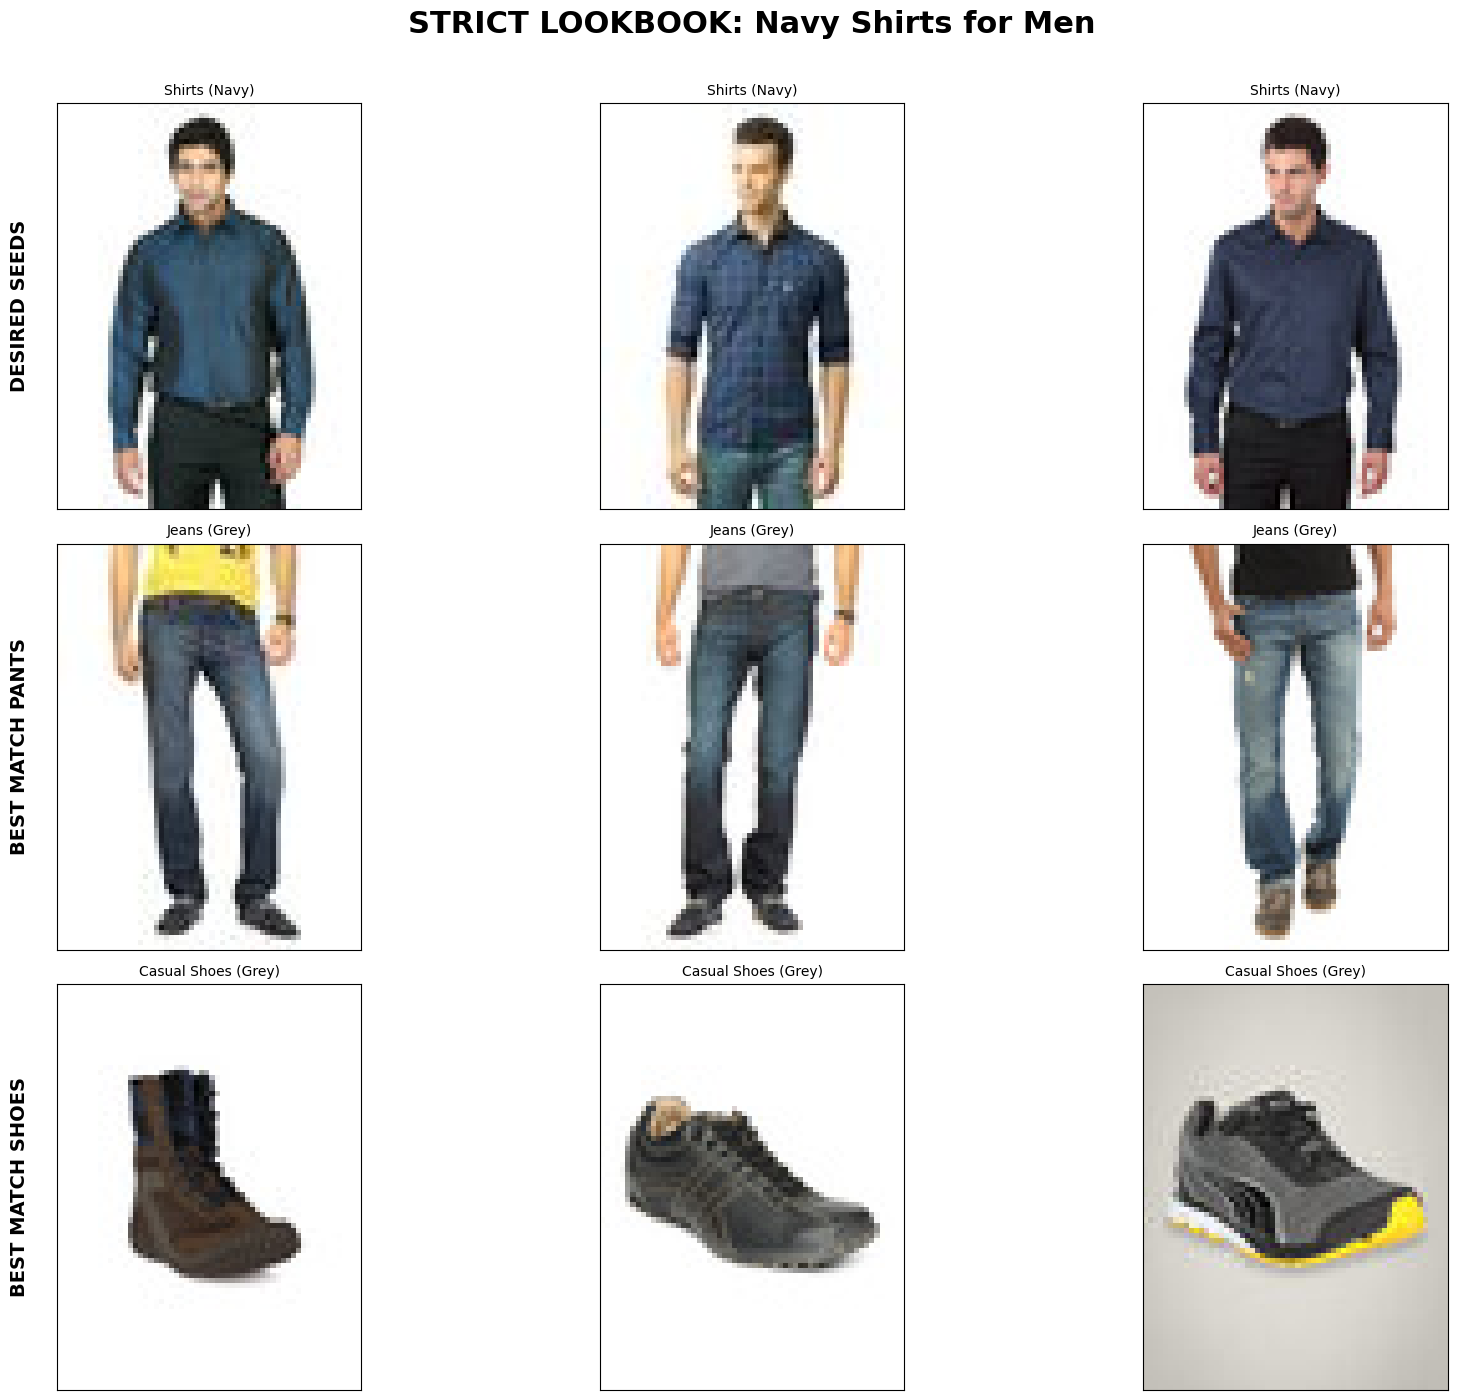

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

def interactive_stylist_v_final():
    print(" --- STRICT 3x3 LOOKBOOK GENERATOR --- ")
    print("(Note: Inputs are CASE-SENSITIVE. Type 'v' to see exact dataset values.)")

    help_cmds = ['v', 'View', 'V', 'view']

    # 1. Inputs (Raw Case Sensitivity)
    while True:
        u_gender = input("\n1. Enter Gender (e.g., Men, Women): ").strip()
        if u_gender in help_cmds:
            print(f"👉 Available in Data: {', '.join(df_subset['gender'].unique())}")
            continue
        break

    while True:
        u_type = input("2. Enter Item Type (e.g., Shirts, Tshirts, Jackets): ").strip()
        if u_type in help_cmds:
            # Show specific Topwear types available for the chosen gender
            available_types = df_subset[df_subset['gender'] == u_gender]['articleType'].unique()[:15]
            print(f"Available {u_gender} Types: {', '.join(available_types)}")
            continue
        break

    while True:
        u_color = input("3. Enter Color (e.g., Navy, Black, White): ").strip()
        if u_color in help_cmds:
            print(f"👉 Available Colors: {', '.join(ideal_colors)}")
            continue
        break

    # --- STRICT SEARCH LOGIC ---
    # We use exact '==' to prevent "Shirt" from matching "Tshirts" accidentally
    seed_pool = df_subset[
        (df_subset['gender'] == u_gender) &
        (df_subset['articleType'] == u_type) &
        (df_subset['final_color_cat'] == u_color)
    ].copy()

    if seed_pool.empty:
        print(f"\n NO MATCH FOUND for: Gender='{u_gender}', Type='{u_type}', Color='{u_color}'")
        print("-" * 50)
        # Diagnostic: Check if the Type even exists in another color
        type_exists = not df_subset[df_subset['articleType'] == u_type].empty
        if not type_exists:
            print(f"💡 Tip: '{u_type}' is not a valid articleType. Try 'Shirts' or 'Tshirts' (plural).")
        else:
            actual_colors = df_subset[df_subset['articleType'] == u_type]['final_color_cat'].unique()
            print(f"💡 Tip: '{u_type}' exists, but only in these colors: {', '.join(actual_colors)}")
        return # Exit to prevent "wrong" seeds from showing

    # Take the top 3 items that matched your request exactly
    seed_items = seed_pool.head(3)

    # Use the first one as the "Style Anchor" for visual similarity
    anchor_idx = seed_items.index[0]
    anchor_vec = style_embeddings[anchor_idx]

    def get_top_3(category):
        # Filter pool by category and gender
        pool = df_subset[
            (df_subset['subCategory'] == category) &
            ((df_subset['gender'] == u_gender) | (df_subset['gender'] == 'Unisex'))
        ].copy()

        if pool.empty: return pd.DataFrame()

        pool_indices = pool.index.tolist()

        # Calculate scores
        style_scores = cosine_similarity([anchor_vec], style_embeddings[pool_indices])[0]
        color_scores = pool['final_color_cat'].apply(lambda x: get_expert_score(u_color, x)).values

        # Combine: 60% Color Rule, 40% Visual Vibe
        pool['final_score'] = (color_scores * 0.6) + (style_scores * 0.4)
        return pool.sort_values('final_score', ascending=False).head(3)

    # 2. Find matching pieces
    top_pants = get_top_3('Bottomwear')
    top_shoes = get_top_3('Shoes')

    # 3. Plotting the 3x3 Grid
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.patch.set_facecolor('#ffffff')
    fig.suptitle(f"STRICT LOOKBOOK: {u_color} {u_type} for {u_gender}", fontsize=22, fontweight='bold', y=0.96)

    rows_data = [seed_items, top_pants, top_shoes]
    row_labels = ["DESIRED SEEDS", "BEST MATCH PANTS", "BEST MATCH SHOES"]

    for row_idx, data in enumerate(rows_data):
        for col_idx in range(3):
            ax = axes[row_idx, col_idx]
            if col_idx < len(data):
                item = data.iloc[col_idx]
                try:
                    img = plt.imread(f"/content/images/{int(item['id'])}.jpg")
                    ax.imshow(img)
                    ax.set_title(f"{item['articleType']} ({item['final_color_cat']})", fontsize=10)
                except:
                    ax.text(0.5, 0.5, "Image Found\nBut Failed to Load", ha='center')
            else:
                ax.text(0.5, 0.5, "No More\nItems Found", ha='center', color='gray')

            # Label the rows on the far left
            if col_idx == 0:
                ax.set_ylabel(row_labels[row_idx], fontsize=14, fontweight='bold', labelpad=20)

            ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the final interactive session
interactive_stylist_v_final()

In [ ]:
import os

folders = [
    'wardrobe/shirts/men', 'wardrobe/shirts/women',
    'wardrobe/tshirts/men', 'wardrobe/tshirts/women',
    'wardrobe/pants/men', 'wardrobe/pants/women',
    'wardrobe/footwear/men', 'wardrobe/footwear/women'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Folders created! Now drag your images into the correct sub-folders in the left sidebar.")

✅ Folders created! Now drag your images into the correct sub-folders in the left sidebar.


In [ ]:
import os
import pandas as pd
import numpy as np
import cv2
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics.pairwise import cosine_similarity

# --- 1. TRAIN THE KNN COLOR MODEL (The Translator) ---
X_train = [
    [0, 0, 128], [0, 0, 255], [255, 255, 255], [0, 0, 0],
    [128, 128, 128], [165, 42, 42], [245, 245, 220], [107, 142, 35],
    [195, 176, 145], [255, 0, 0], [0, 128, 0], [128, 0, 0], [200, 200, 200]
]
y_train = [
    'Navy', 'Blue', 'White', 'Black',
    'Grey', 'Brown', 'Beige', 'Olive',
    'Khaki', 'Red', 'Green', 'Maroon', 'Pattern'
]
knn_color_model = KNeighborsClassifier(n_neighbors=1).fit(X_train, y_train)

def knn_color_predictor(rgb):
    return knn_color_model.predict([rgb])[0]

# --- 2. KNIT THE WARDROBE (The Database) ---
def knit_wardrobe(base_path='wardrobe'):
    data = []
    cat_map = {
        'shirts': ('Apparel', 'Topwear', 'Shirts'),
        'tshirts': ('Apparel', 'Topwear', 'Tshirts'),
        'pants': ('Apparel', 'Bottomwear', 'Pants'),
        'footwear': ('Footwear', 'Shoes', 'Casual Shoes')
    }
    for cat_folder, (master, sub, article) in cat_map.items():
        for gender in ['men', 'women']:
            path = os.path.join(base_path, cat_folder, gender)
            if not os.path.exists(path): continue
            for img_name in os.listdir(path):
                if img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                    data.append({
                        'id': img_name.split('.')[0],
                        'gender': gender.capitalize(),
                        'subCategory': sub,
                        'articleType': article,
                        'image_path': os.path.join(path, img_name)
                    })
    return pd.DataFrame(data)

# --- 3. STYLE DNA EXTRACTOR (Visual Vibe) ---
# Using weights=MobileNet_V2_Weights.DEFAULT to fix your UserWarning
style_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT).features
style_model.eval()
preprocess = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def get_style_vector(img_path):
    try:
        img = Image.open(img_path).convert('RGB')
        tensor = preprocess(img).unsqueeze(0)
        with torch.no_grad():
            features = style_model(tensor)
        return features.mean([2, 3]).flatten().numpy()
    except: return np.zeros(1280)

# --- 4. EXECUTE FULL PIPELINE ---
print("🚀 Starting User Wardrobe Incorporation...")
df_subset = knit_wardrobe('wardrobe')

if df_subset.empty:
    print("❌ ERROR: No images found in /wardrobe folders. Please upload your items first!")
else:
    print("🎨 Extracting Color DNA (K-Means + KNN)...")
    # Using your get_dominant_color_focused logic
    df_subset['rgb'] = df_subset['image_path'].apply(lambda x: get_dominant_color_focused(x))
    df_subset['final_color_cat'] = df_subset['rgb'].apply(knn_color_predictor)

    print("🖼️ Generating Style DNA (Visual Vibe)...")
    style_embeddings = np.array([get_style_vector(p) for p in df_subset['image_path']])

    print(f"✅ Closet Ready! {len(df_subset)} items indexed.")
    print(df_subset['final_color_cat'].value_counts())

🚀 Starting User Wardrobe Incorporation...
🎨 Extracting Color DNA (K-Means + KNN)...
🖼️ Generating Style DNA (Visual Vibe)...
✅ Closet Ready! 41 items indexed.
final_color_cat
Black      11
Pattern    10
Beige       4
Khaki       4
Brown       3
Olive       3
Grey        3
Navy        2
Maroon      1
Name: count, dtype: int64


👔 --- MY VIRTUAL CLOSET EXPLORER --- 👔
(Type 'v' at any prompt to see your available inventory)

1. Gender (Men/Women): Men
2. Item Type for Men (e.g., Shirts, Tshirts): Shirts
✅ Selected: Shirts
3. Color of Shirts: v
👉 Available colors for your Men Shirts: Pattern, Olive, Brown, Black, Beige
3. Color of Shirts: Olive


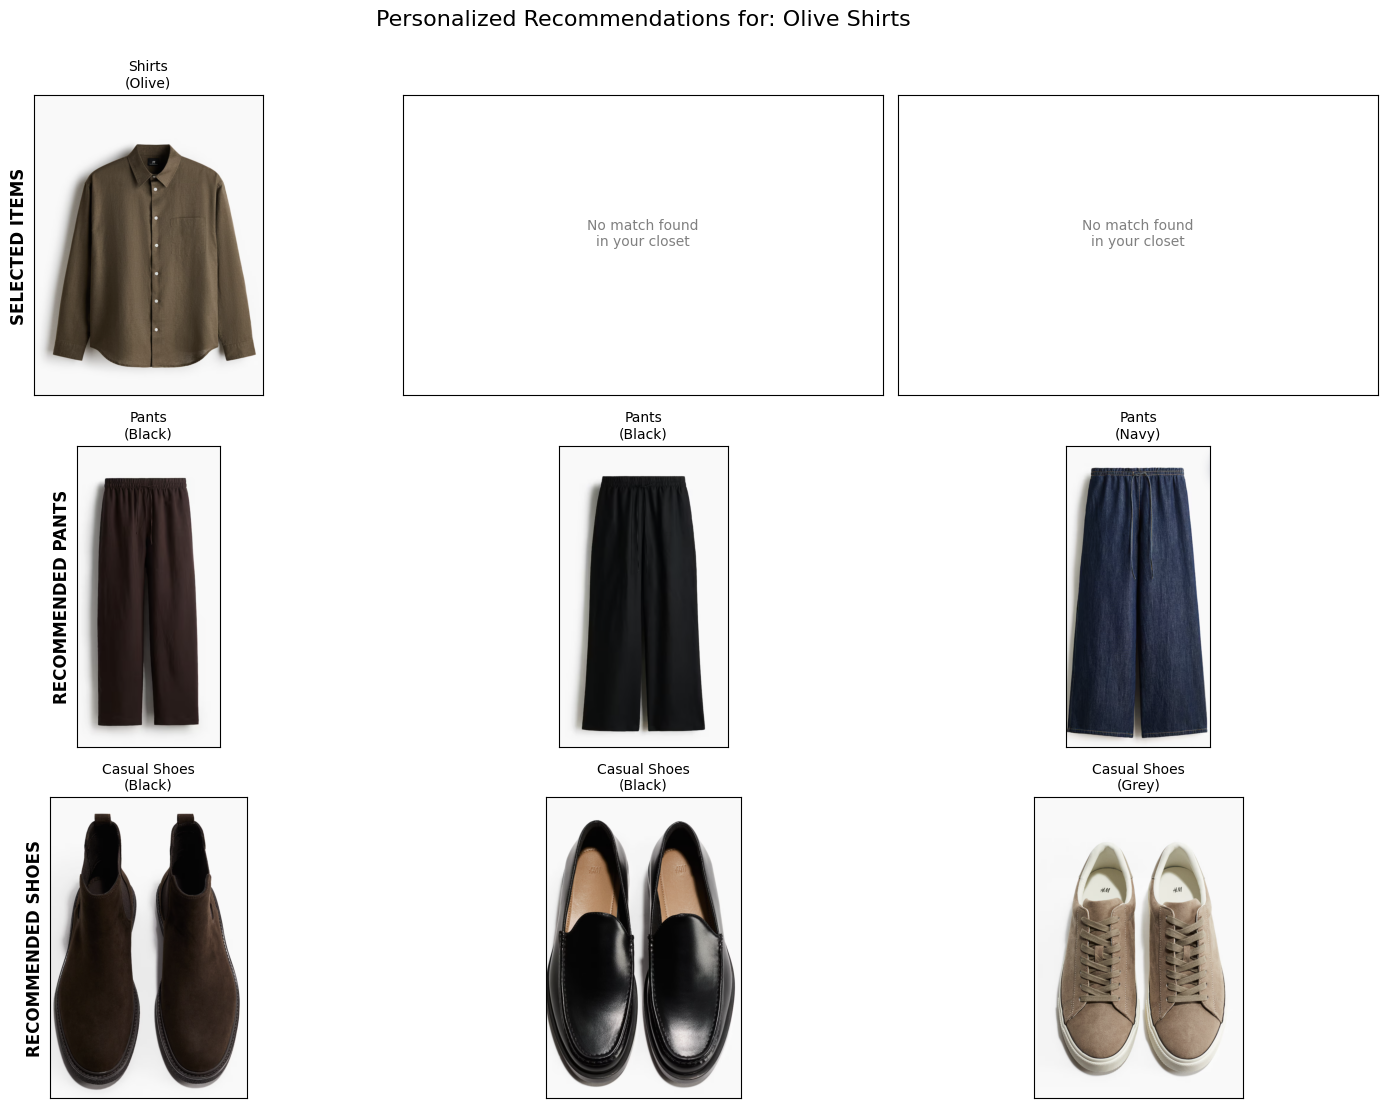

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def my_personal_stylist_v3():
    print("👔 --- MY VIRTUAL CLOSET EXPLORER --- 👔")
    print("(Type 'v' at any prompt to see your available inventory)")

    help_cmds = ['v', 'view', 'V', 'View']

    # 1. Gender Selection
    while True:
        u_gender = input("\n1. Gender (Men/Women): ").strip().capitalize()
        if u_gender in help_cmds:
            options = df_subset['gender'].unique()
            print(f"👉 You have items for: {', '.join(options)}")
            continue
        if u_gender not in df_subset['gender'].unique():
            print(f"❌ No items found for '{u_gender}'. Try 'v' to see options.")
            continue
        break

    # 2. Item Type Selection (Case-Insensitive Upgrade)
    while True:
        u_type_raw = input(f"2. Item Type for {u_gender} (e.g., Shirts, Tshirts): ").strip()

        if u_type_raw.lower() in help_cmds:
            options = df_subset[df_subset['gender'] == u_gender]['articleType'].unique()
            print(f"👉 Your {u_gender} closet contains: {', '.join(options)}")
            continue

        # SMART SEARCH: Find the actual name in the dataset regardless of case
        valid_types = df_subset[df_subset['gender'] == u_gender]['articleType'].unique()

        # Check if what the user typed matches any valid type (ignoring case)
        match = next((t for t in valid_types if t.lower() == u_type_raw.lower()), None)

        if match:
            u_type = match # Set u_type to the EXACT string from the dataset
            print(f"✅ Selected: {u_type}")
            break
        else:
            print(f"❌ '{u_type_raw}' not found. Try 'v' to see the list.")
            continue

    # 3. Color Selection
    while True:
        u_color = input(f"3. Color of {u_type}: ").strip().capitalize()
        if u_color in help_cmds:
            options = df_subset[
                (df_subset['gender'] == u_gender) &
                (df_subset['articleType'] == u_type)
            ]['final_color_cat'].unique()
            print(f"👉 Available colors for your {u_gender} {u_type}: {', '.join(options)}")
            continue
        break

    # --- PROCESSING ---
    seed_pool = df_subset[
        (df_subset['gender'] == u_gender) &
        (df_subset['articleType'] == u_type) &
        (df_subset['final_color_cat'] == u_color)
    ].copy()

    if seed_pool.empty:
        print(f"❌ Error: No matching {u_color} {u_type} found. Restarting...")
        return

    seed_items = seed_pool.head(3)
    anchor_idx = seed_items.index[0]
    anchor_vec = style_embeddings[anchor_idx]

    def get_top_3(category):
        # Filter by category and gender
        pool = df_subset[
            (df_subset['subCategory'] == category) &
            (df_subset['gender'] == u_gender)
        ].copy()

        if pool.empty: return pd.DataFrame()

        pool_indices = pool.index.tolist()

        # Calculate matching scores
        style_scores = cosine_similarity([anchor_vec], style_embeddings[pool_indices])[0]
        color_scores = pool['final_color_cat'].apply(lambda x: get_expert_score(u_color, x)).values

        # Combine scores (60% Color Logic / 40% Visual Vibe)
        pool['final_score'] = (color_scores * 0.6) + (style_scores * 0.4)
        return pool.sort_values('final_score', ascending=False).head(3)

    # Fetch matches from your closet
    top_pants = get_top_3('Bottomwear')
    top_shoes = get_top_3('Shoes')

    # --- VISUALIZATION ---
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.patch.set_facecolor('#ffffff')

    rows_data = [seed_items, top_pants, top_shoes]
    row_labels = ["SELECTED ITEMS", "RECOMMENDED PANTS", "RECOMMENDED SHOES"]

    for row_idx, data in enumerate(rows_data):
        for col_idx in range(3):
            ax = axes[row_idx, col_idx]
            if col_idx < len(data):
                item = data.iloc[col_idx]
                try:
                    img = plt.imread(item['image_path'])
                    ax.imshow(img)
                    ax.set_title(f"{item['articleType']}\n({item['final_color_cat']})", fontsize=10)
                except:
                    ax.text(0.5, 0.5, "Image Error", ha='center')
            else:
                ax.text(0.5, 0.5, "No match found\nin your closet", ha='center', color='gray')

            if col_idx == 0:
                ax.set_ylabel(row_labels[row_idx], fontsize=12, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle(f"Personalized Recommendations for: {u_color} {u_type}", fontsize=16, y=0.95)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the updated stylist
my_personal_stylist_v3()